In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
data=pd.read_csv('Country-data.csv')

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [10]:
data.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


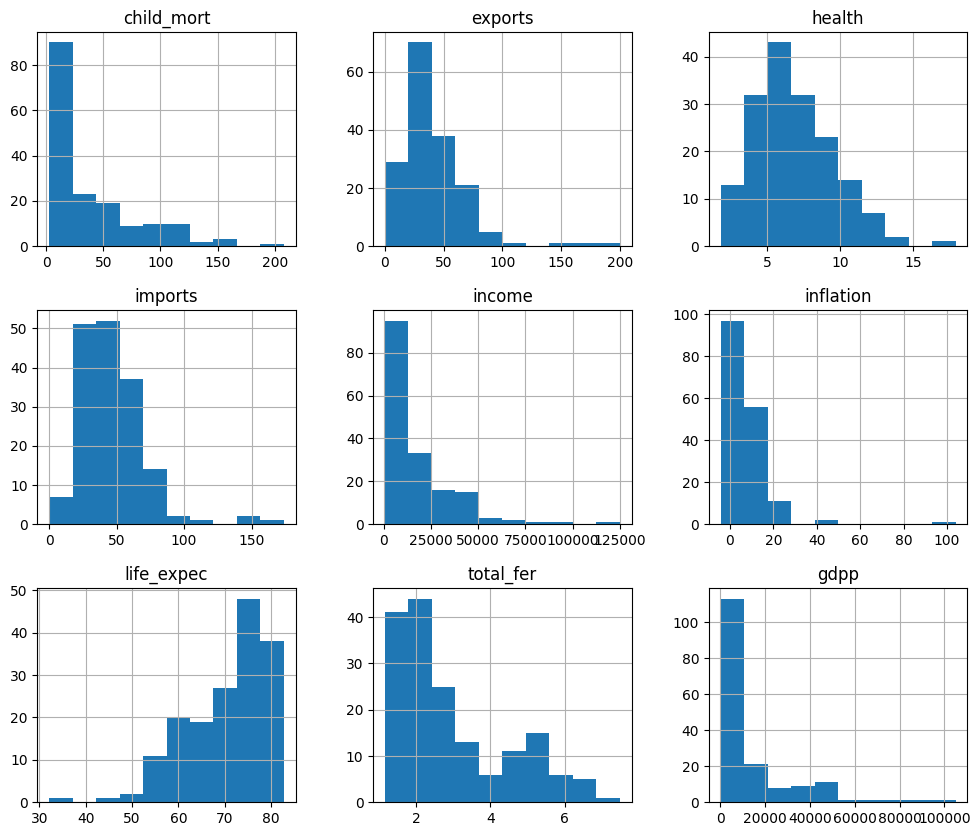

In [11]:
import matplotlib.pyplot as plt

data.hist(figsize=(12,10))
plt.show()

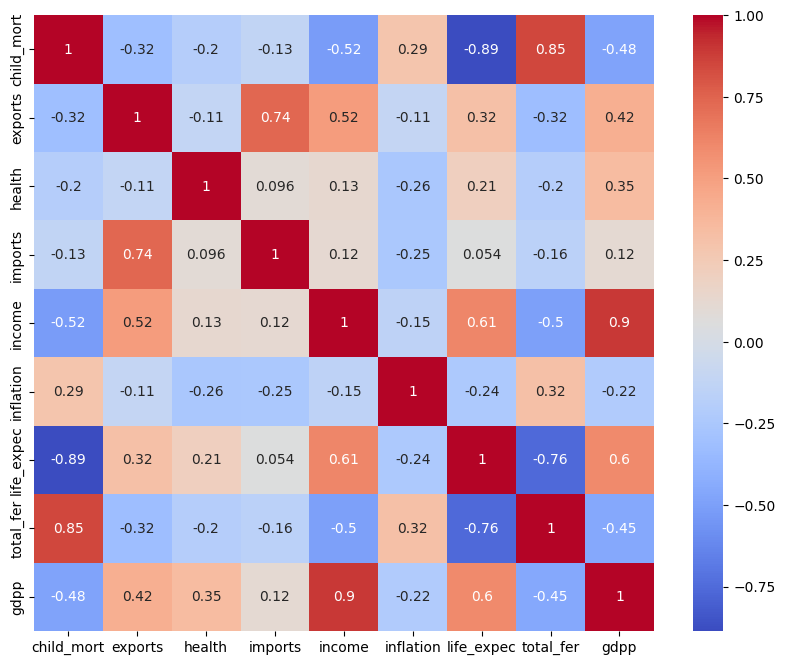

In [12]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

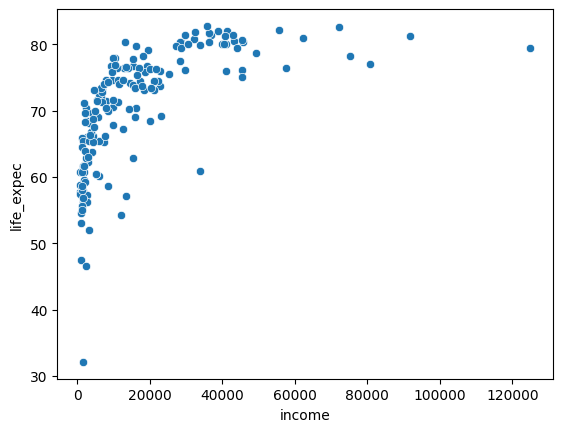

In [13]:
sns.scatterplot(x='income', y='life_expec', data=data)
plt.show()

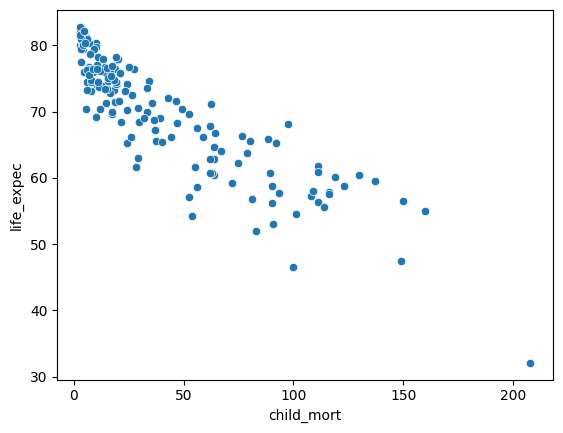

In [14]:
sns.scatterplot(x='child_mort', y='life_expec', data=data)
plt.show()

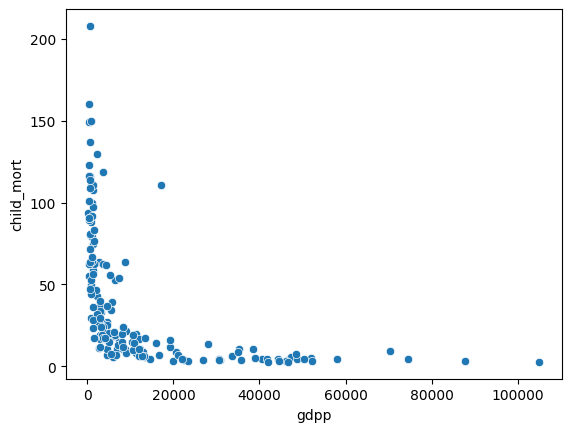

In [15]:
sns.scatterplot(x='gdpp', y='child_mort', data=data)
plt.show()

In [36]:
countries = data['country']

In [37]:
data = data.drop('country', axis=1)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

In [39]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

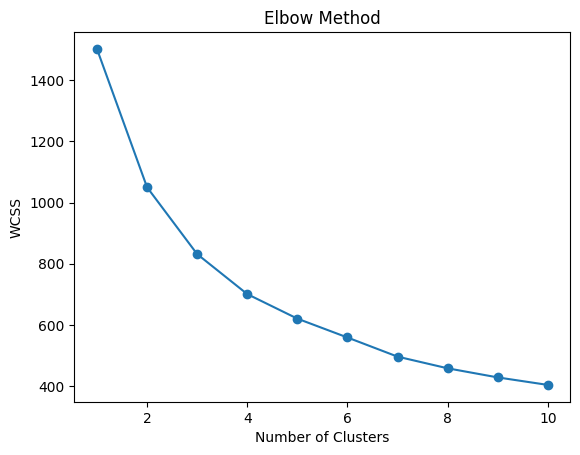

In [40]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [41]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, score={score}")

k=2, score=0.28735668921406704
k=3, score=0.28329575683463126
k=4, score=0.29595170577528157
k=5, score=0.2992594995920442
k=6, score=0.22869157246806018


In [42]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

data['cluster'] = labels

In [43]:
cluster_summary = data.groupby('cluster').mean()
print(cluster_summary)

         child_mort    exports    health    imports        income  inflation  \
cluster                                                                        
0          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
1         92.961702  29.151277  6.388511  42.323404   3942.404255  12.019681   
2         21.927381  40.243917  6.200952  47.473404  12305.595238   7.600905   

         life_expec  total_fer          gdpp  
cluster                                       
0         80.127778   1.752778  42494.444444  
1         59.187234   5.008085   1922.382979  
2         72.814286   2.307500   6486.452381  


In [48]:
cluster_map = {
    0: "Developed",
    1: "Underdeveloped",
    2: "Developing"
}

data['category'] = data['cluster'].map(cluster_map)

In [49]:
data['country'] = countries

In [50]:
data[['country', 'cluster', 'category']].sort_values(by='category')

,country,cluster,category
134,Slovak Republic,0,Developed
23,Brunei,0,Developed
82,Kuwait,0,Developed
54,France,0,Developed
53,Finland,0,Developed
...,...,...,...
80,Kenya,1,Underdeveloped
72,Iraq,1,Underdeveloped
66,Haiti,1,Underdeveloped
88,Liberia,1,Underdeveloped


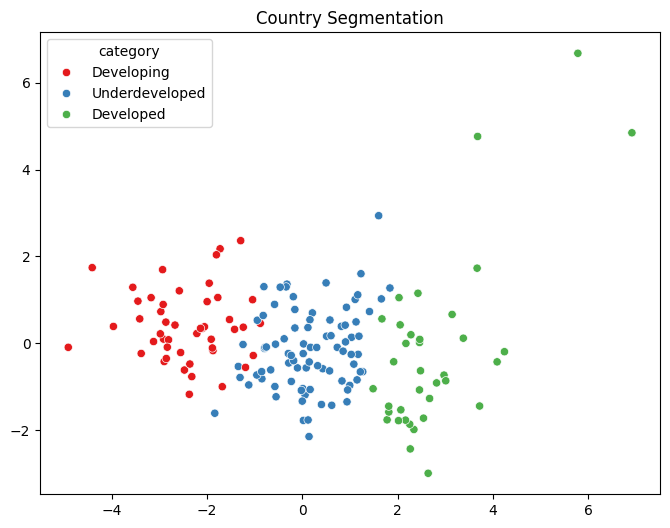

In [27]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0], 
    y=X_pca[:,1], 
    hue=data['category'], 
    palette='Set1'
)
plt.title("Country Segmentation")
plt.show()

In [51]:
data[['country', 'category']].sort_values(by='category')

,country,category
134,Slovak Republic,Developed
23,Brunei,Developed
82,Kuwait,Developed
54,France,Developed
53,Finland,Developed
...,...,...
80,Kenya,Underdeveloped
72,Iraq,Underdeveloped
66,Haiti,Underdeveloped
88,Liberia,Underdeveloped


In [31]:
countries = data['country']

In [32]:
data['country'] = countries

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [53]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.4595174  0.17181626]
0.6313336543771411


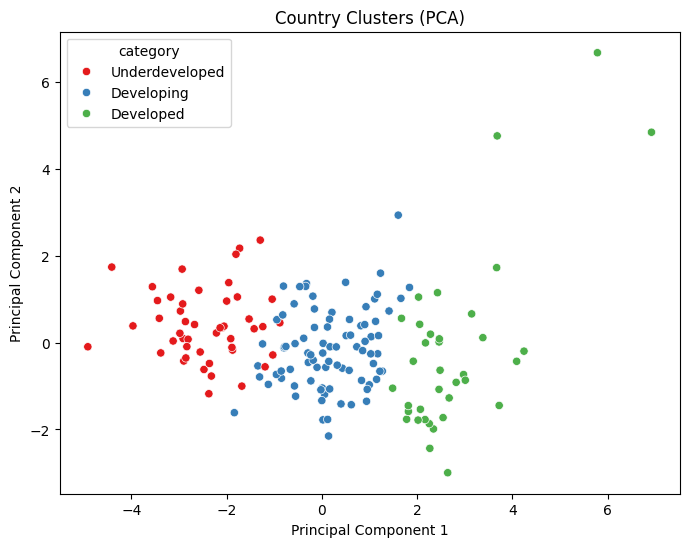

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=data['category'],
    palette='Set1'
)
plt.title("Country Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [55]:
pd.DataFrame(
    pca.components_,
    columns=data.drop(['cluster','category','country'], axis=1).columns
)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,-0.419519,0.283897,0.150838,0.161482,0.398441,-0.193173,0.425839,-0.403729,0.392645
1,0.192884,0.613163,-0.243087,0.671821,0.022536,-0.008404,-0.222707,0.155233,-0.046022


In [56]:
pca.components_

array([[-0.41951945,  0.28389698,  0.15083782,  0.16148244,  0.39844111,
        -0.19317293,  0.42583938, -0.40372896,  0.39264482],
       [ 0.19288394,  0.61316349, -0.24308678,  0.67182064,  0.02253553,
        -0.00840447, -0.22270674,  0.15523311, -0.0460224 ]])